Dataset Created
   User_ID Group  Converted  Checkout_Time
0        1     A          0       5.752284
1        2     B          0       4.661300
2        3     A          0       5.144124
3        4     A          1       4.581989
4        5     A          0       2.747623

Before Cleaning: 5020
After Cleaning: 5000

Conversion Summary
       Total_Users  Purchases  Conversion_Rate
Group                                         
A             2504        306        12.220447
B             2496        345        13.822115


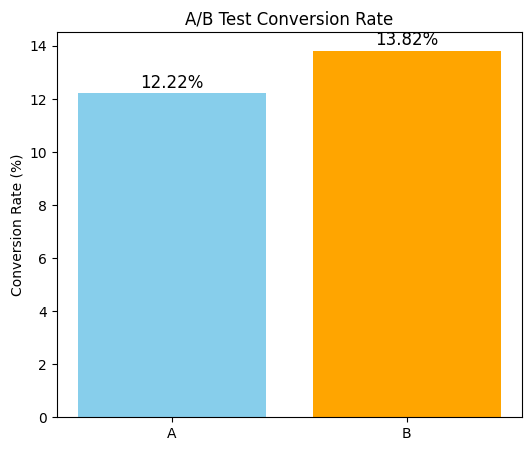


Hypothesis Testing
Z Statistic : -1.6827
P Value : 0.092429

Fail to Reject Null Hypothesis
No significant difference found.

Business Recommendation

No statistically significant difference exists.

Recommendation:
Continue testing with a larger sample size before
making business decisions.



In [1]:
# ==========================================
# A/B TESTING & HYPOTHESIS TESTING PROJECT
# Website Checkout Conversion Analysis
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Reproducibility
np.random.seed(42)

# ==========================================
# STEP 1 : Create Sample Dataset
# ==========================================

n = 5000

group = np.random.choice(['A', 'B'], size=n)

# Group A conversion = 12%
# Group B conversion = 15%

conversion = []

for g in group:
    if g == 'A':
        conversion.append(np.random.binomial(1, 0.12))
    else:
        conversion.append(np.random.binomial(1, 0.15))

checkout_time = np.random.normal(4.5,1,n)

df = pd.DataFrame({
    "User_ID": range(1,n+1),
    "Group": group,
    "Converted": conversion,
    "Checkout_Time": checkout_time
})

# Introduce some duplicate rows
df = pd.concat([df, df.iloc[:20]])

print("Dataset Created")
print(df.head())

# ==========================================
# STEP 2 : Data Cleaning
# ==========================================

print("\nBefore Cleaning:",len(df))

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print("After Cleaning:",len(df))

# ==========================================
# STEP 3 : Conversion Rate
# ==========================================

summary = df.groupby("Group")["Converted"].agg(
    Total_Users='count',
    Purchases='sum',
    Conversion_Rate='mean'
)

summary["Conversion_Rate"] *=100

print("\nConversion Summary")
print(summary)

# ==========================================
# STEP 4 : Visualization
# ==========================================

plt.figure(figsize=(6,5))

plt.bar(summary.index,
        summary["Conversion_Rate"],
        color=["skyblue","orange"])

plt.ylabel("Conversion Rate (%)")
plt.title("A/B Test Conversion Rate")

for i,v in enumerate(summary["Conversion_Rate"]):
    plt.text(i,v+0.2,f"{v:.2f}%",ha='center',fontsize=12)

plt.show()

# ==========================================
# STEP 5 : Hypothesis Testing
# ==========================================

# H0 : Conversion rates are equal
# H1 : Conversion rates are different

success = summary["Purchases"].values
samples = summary["Total_Users"].values

z_stat,p_value = proportions_ztest(success,samples)

print("\n==========================")
print("Hypothesis Testing")
print("==========================")

print("Z Statistic :",round(z_stat,4))
print("P Value :",round(p_value,6))

alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis")
    print("There is a statistically significant difference.")
else:
    print("\nFail to Reject Null Hypothesis")
    print("No significant difference found.")

# ==========================================
# STEP 6 : Business Recommendation
# ==========================================

rateA = summary.loc["A","Conversion_Rate"]
rateB = summary.loc["B","Conversion_Rate"]

print("\n==========================")
print("Business Recommendation")
print("==========================")

if rateB > rateA and p_value < alpha:
    print(f"""
Version B performs significantly better.

Version A Conversion : {rateA:.2f}%
Version B Conversion : {rateB:.2f}%

Recommendation:
Deploy Version B for all users because it
improves checkout conversion while the
difference is statistically significant.
""")

elif rateA > rateB and p_value < alpha:

    print(f"""
Version A performs significantly better.

Recommendation:
Keep Version A as the default checkout page.
""")

else:

    print("""
No statistically significant difference exists.

Recommendation:
Continue testing with a larger sample size before
making business decisions.
""")